# Optimum Captain Set — Playground #4

Captaincy is worth **~2× points on one player** — the single biggest weekly decision. If a
handful of premiums between them cover *every* gameweek with an easy fixture, we never have to
buy a fresh captain: we just rotate the armband inside a small owned set.

**CS problem:** this is **minimum set cover** (NP-hard). The *universe* is the gameweeks in our
horizon; each candidate player is a *set* — the GWs where their team has an easy fixture. We want
the **fewest players** whose easy-GWs union to the whole horizon.

- **Data structure:** a boolean **coverage matrix** `players × GW`. Rows stored as **bitsets**
  turn "does this set of players cover everything?" into a single bitwise-OR.
- **Two algorithms, side by side:** **greedy** (repeatedly grab the player covering the most
  still-uncovered GWs — the classic `ln n` approximation) vs an **exact ILP** (scipy `milp`).
  The teaching beat: *when does the intuitive greedy pick match the true optimum, and when does
  it waste a slot?*
- **Tie-break:** among all minimum-size covers, prefer the one with the highest **projected
  captain points**, so the answer is not just small but actually the set you'd want to own.

Candidate pool is restricted to the premium attackers of five template clubs:
**Arsenal, Man Utd, Man City, Liverpool, Chelsea**.

## Config — edit me

In [13]:
FIXTURES_URL = "https://fantasy.premierleague.com/api/fixtures/"
BOOTSTRAP_URL = "https://fantasy.premierleague.com/api/bootstrap-static/"

# The five clubs whose players are captain candidates (short_name in the FPL API).
CANDIDATE_TEAMS = ["ARS", "MUN", "MCI", "LIV", "CHE"]

# A fixture is a "good captain GW" when the team's FDR is at or below this. 3 = looser, 2 = strict.
DIFFICULTY_THRESHOLD = 2

# How many upcoming gameweeks to cover, starting from the next GW.
HORIZON = 8

# DGW aggregation: collapse two fixtures in one GW into one FDR cell.
# "min" = a DGW counts as easy if EITHER game is easy (captaincy loves two chances to haul).
# "max" = only easy if BOTH games are soft (conservative).
DGW_AGG = "min"

# Candidate pool filter. Keep only attacking players (MID/FWD) at or above this price,
# then keep at most TOP_N_PER_TEAM per club ranked by projected captain score.
POSITIONS = {3, 4}          # 1 GK, 2 DEF, 3 MID, 4 FWD
MIN_PRICE = 6.0             # in £m; premiums/mid-price attackers only
TOP_N_PER_TEAM = 3          # cap candidates per club so the pool stays a teaching-sized set

# How to score a player as a captain each GW (used for the tie-break and per-GW pick).
# We combine a season-long expected-points proxy with how soft the specific fixture is.
# score = CAPTAIN_STRENGTH * (5 - fdr)  -> better player AND softer fixture both help.
def captain_strength(p):
    """A single 'how good a captain is this player' number from the bootstrap row."""
    ep = float(p.get("ep_next") or 0)          # FPL's own expected points next GW
    form = float(p.get("form") or 0)
    xgi = float(p.get("expected_goal_involvements") or 0)
    return ep + 0.5 * form + 0.1 * xgi

## Fetch

In [14]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

HEADERS = {"User-Agent": "Mozilla/5.0"}

boot = requests.get(BOOTSTRAP_URL, headers=HEADERS, timeout=30).json()
fixtures = requests.get(FIXTURES_URL, headers=HEADERS, timeout=30).json()

team_name = {t["id"]: t["short_name"] for t in boot["teams"]}
name_to_id = {t["short_name"]: t["id"] for t in boot["teams"]}
cand_team_ids = {name_to_id[s] for s in CANDIDATE_TEAMS if s in name_to_id}

next_gw = next((e["id"] for e in boot["events"] if e.get("is_next")), None)
if next_gw is None:
    next_gw = next((e["id"] for e in boot["events"] if not e["finished"]), 1)
gw_max = next_gw + HORIZON - 1
gws = list(range(next_gw, gw_max + 1))

print(f"{len(fixtures)} fixtures, {len(team_name)} teams.")
print(f"Next GW = {next_gw}, horizon = GW{next_gw}-{gw_max}.")
print(f"Candidate clubs: {sorted(team_name[i] for i in cand_team_ids)}")

380 fixtures, 20 teams.
Next GW = 1, horizon = GW1-8.
Candidate clubs: ['ARS', 'CHE', 'LIV', 'MCI', 'MUN']


## Per-team difficulty ticker (candidate clubs only)

Same fixture-difficulty pivot as the fixture-run notebook, but restricted to our five clubs.
Each fixture yields one row per team from that team's own perspective (home carries
`team_h_difficulty`, away `team_a_difficulty`). **DGW** cells collapse per `DGW_AGG`;
**BGW** cells are `NaN` (no fixture, so no captain that week).

In [15]:
rows = []
for f in fixtures:
    gw = f["event"]
    if gw is None or gw < next_gw or gw > gw_max:
        continue
    for team, opp, where, fdr in [
        (f["team_h"], f["team_a"], "H", f["team_h_difficulty"]),
        (f["team_a"], f["team_h"], "A", f["team_a_difficulty"]),
    ]:
        if team in cand_team_ids:
            rows.append({"team": team, "gw": gw, "opp": opp, "where": where, "fdr": fdr})

long = pd.DataFrame(rows)
long["team"] = long["team"].map(team_name)
long["opp"] = long["opp"].map(team_name)
long["label"] = long["opp"] + " (" + long["where"] + ")"

agg = "min" if DGW_AGG == "min" else "max"
team_fdr = long.pivot_table(index="team", columns="gw", values="fdr", aggfunc=agg).reindex(columns=gws)
team_labels = long.groupby(["team", "gw"])["label"].apply(lambda s: " + ".join(s)).unstack().reindex(columns=gws)
team_fdr = team_fdr.loc[team_fdr.mean(axis=1).sort_values().index]
team_labels = team_labels.reindex(team_fdr.index)
team_fdr.round(1)

gw,1,2,3,4,5,6,7,8
team,,,,,,,,
LIV,3,3,2,2,3,4,3,2
MUN,2,2,3,4,3,3,3,3
ARS,2,4,4,3,3,2,3,3
CHE,3,2,5,2,3,3,3,3
MCI,3,3,2,4,2,4,2,4


## Build the candidate player pool

From the five clubs we keep attacking players (MID/FWD) priced at least `MIN_PRICE`, drop anyone
flagged unavailable, then keep the top `TOP_N_PER_TEAM` per club by `captain_strength`. Every
player inherits their **club's** fixture row — two Arsenal players cover exactly the same GWs, so
the interesting question the optimizer answers is *which* player from each chosen club to lock in.

In [16]:
T = DIFFICULTY_THRESHOLD
pool = []
for p in boot["elements"]:
    if p["team"] not in cand_team_ids:
        continue
    if p["element_type"] not in POSITIONS:
        continue
    if p["now_cost"] / 10.0 < MIN_PRICE:
        continue
    if p.get("status") in {"i", "u", "n", "s"}:   # injured / unavailable / not in squad / suspended
        continue
    pool.append({
        "id": p["id"],
        "name": p["web_name"],
        "team": team_name[p["team"]],
        "pos": {1: "GK", 2: "DEF", 3: "MID", 4: "FWD"}[p["element_type"]],
        "price": p["now_cost"] / 10.0,
        "sel%": float(p.get("selected_by_percent") or 0),
        "strength": round(captain_strength(p), 2),
    })

pool = pd.DataFrame(pool).sort_values(["team", "strength"], ascending=[True, False])
pool = pool.groupby("team", group_keys=False).head(TOP_N_PER_TEAM).reset_index(drop=True)
print(f"Candidate pool: {len(pool)} players across {pool['team'].nunique()} clubs")
pool

Candidate pool: 15 players across 5 clubs


,id,name,team,pos,price,sel%,strength
0,12,Saka,ARS,MID,9.5,11.4,4.67
1,25,Gyökeres,ARS,FWD,7.5,16.2,3.72
2,13,Rice,ARS,MID,7.5,23.6,3.65
3,154,Palmer,CHE,MID,9.5,13.2,4.50
4,155,Enzo,CHE,MID,7.0,5.3,4.25
5,165,João Pedro,CHE,FWD,7.5,46.0,3.99
6,366,Wirtz,LIV,MID,7.5,14.2,3.80
7,367,Gakpo,LIV,MID,7.0,4.2,3.70
8,368,Szoboszlai,LIV,MID,7.0,37.3,3.56
9,411,Haaland,MCI,FWD,15.5,71.1,6.82


## Coverage matrix — `players × GW`

The heart of set cover. Cell `(player, gw) = 1` when that player's club has a **good captain
fixture** that week (`FDR ≤ T`, DGWs already collapsed). We also store each row as an integer
**bitset** (`bit g-next_gw` set when the player covers GW `g`) so that testing whether a group of
players covers everything is one bitwise-OR against the `FULL` mask.

The **universe** is only the GWs that *someone* in the pool can cover — if no candidate club has
an easy game in some GW, that week is simply uncoverable by this pool and we set it aside rather
than declare the problem infeasible.

In [17]:
# Per-player GW coverage, inherited from the club row.
cover = pd.DataFrame(
    {gw: [(pd.notna(team_fdr.loc[r.team, gw]) and team_fdr.loc[r.team, gw] <= T)
          for r in pool.itertuples()] for gw in gws},
    index=pool["name"],
)

coverable = [gw for gw in gws if cover[gw].any()]
uncoverable = [gw for gw in gws if gw not in coverable]

def bitset(row):
    b = 0
    for j, gw in enumerate(gws):
        if row[gw]:
            b |= (1 << j)
    return b

pool["bits"] = [bitset(cover.loc[r.name]) for r in pool.itertuples()]
UNIVERSE = 0
for gw in coverable:
    UNIVERSE |= (1 << gws.index(gw))

print(f"Universe to cover: {len(coverable)} GWs -> {[f'GW{g}' for g in coverable]}")
if uncoverable:
    print(f"Uncoverable by this pool (no easy fixture any candidate club): {[f'GW{g}' for g in uncoverable]}")
cover.astype(int)

Universe to cover: 8 GWs -> ['GW1', 'GW2', 'GW3', 'GW4', 'GW5', 'GW6', 'GW7', 'GW8']


,1,2,3,4,5,6,7,8
name,,,,,,,,
Saka,1,0,0,0,0,1,0,0
Gyökeres,1,0,0,0,0,1,0,0
Rice,1,0,0,0,0,1,0,0
Palmer,0,1,0,1,0,0,0,0
Enzo,0,1,0,1,0,0,0,0
João Pedro,0,1,0,1,0,0,0,0
Wirtz,0,0,1,1,0,0,0,1
Gakpo,0,0,1,1,0,0,0,1
Szoboszlai,0,0,1,1,0,0,0,1


## Per-GW captain scores

For the tie-break and the final rota we need *how good* each player is as captain in each GW, not
just whether the fixture is easy. We score every covered cell as `strength × (5 − FDR)` — a
strong player in a very soft fixture scores highest. Uncovered cells are `0`.

In [18]:
strength = pool.set_index("name")["strength"]
gw_score = pd.DataFrame(0.0, index=pool["name"], columns=gws)
for r in pool.itertuples():
    for gw in gws:
        if cover.loc[r.name, gw]:
            fdr = team_fdr.loc[r.team, gw]
            gw_score.loc[r.name, gw] = round(strength[r.name] * (5 - fdr), 2)
gw_score.round(1)

,1,2,3,4,5,6,7,8
name,,,,,,,,
Saka,14.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0
Gyökeres,11.2,0.0,0.0,0.0,0.0,11.2,0.0,0.0
Rice,11.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0
Palmer,0.0,13.5,0.0,13.5,0.0,0.0,0.0,0.0
Enzo,0.0,12.8,0.0,12.8,0.0,0.0,0.0,0.0
João Pedro,0.0,12.0,0.0,12.0,0.0,0.0,0.0,0.0
Wirtz,0.0,0.0,11.4,11.4,0.0,0.0,0.0,11.4
Gakpo,0.0,0.0,11.1,11.1,0.0,0.0,0.0,11.1
Szoboszlai,0.0,0.0,10.7,10.7,0.0,0.0,0.0,10.7


## Algorithm 1 — Greedy set cover

The textbook `ln n`-approximation: repeatedly take the player who covers the **most
still-uncovered** GWs; break ties by the higher captain-score over those newly-covered GWs. Stop
when the union hits the universe. Fast and usually good — but greedy commits to a locally big set
first and can end up one slot heavier than necessary.

In [19]:
def popcount(x):
    return bin(x).count("1")

def greedy_cover():
    remaining = UNIVERSE
    chosen = []
    names = list(pool["name"])
    bits = dict(zip(names, pool["bits"]))
    while remaining:
        best, best_key = None, None
        for n in names:
            if n in chosen:
                continue
            new = bits[n] & remaining
            if new == 0:
                continue
            gained = popcount(new)
            score = sum(gw_score.loc[n, gws[j]] for j in range(len(gws)) if new & (1 << j))
            key = (gained, score)
            if best_key is None or key > best_key:
                best_key, best = key, n
        if best is None:
            break
        chosen.append(best)
        remaining &= ~bits[best]
    return chosen

greedy = greedy_cover()
print(f"Greedy cover: {len(greedy)} players -> {greedy}")

Greedy cover: 4 players -> ['Haaland', 'B.Fernandes', 'Wirtz', 'Saka']


## Algorithm 2 — Exact minimum cover (ILP)

The true optimum via integer linear programming with scipy's `milp`. Binary `x_p` per player;
**cover constraint** for each universe GW `g`: `sum of x_p over players covering g ≥ 1`. We
optimize a **lexicographic** objective in one shot: minimize `BIG·(player count) − (total captain
score)`, where `BIG` dwarfs any achievable score. So the solver first drives the set as small as
possible, and *only then* — among all minimum-size covers — maximizes projected captain points.

In [20]:
from scipy.optimize import milp, LinearConstraint, Bounds

names = list(pool["name"])
P = len(names)
bits = list(pool["bits"])

# Each player's total captain score across the GWs they cover (tie-break reward).
tot_score = np.array([
    sum(gw_score.loc[names[i], gws[j]] for j in range(len(gws)) if bits[i] & (1 << j))
    for i in range(P)
])
BIG = tot_score.sum() + 1.0            # bigger than any score total -> size always dominates
c = BIG - tot_score                    # minimize BIG*count - score

# Cover constraint: for each universe GW, at least one chosen player covers it.
A = np.array([[1.0 if (bits[i] & (1 << gws.index(g))) else 0.0 for i in range(P)]
              for g in coverable])
constraints = LinearConstraint(A, lb=np.ones(len(coverable)), ub=np.full(len(coverable), np.inf))

res = milp(c=c, constraints=constraints, integrality=np.ones(P),
           bounds=Bounds(lb=np.zeros(P), ub=np.ones(P)))

optimal = [names[i] for i in range(P) if res.x[i] > 0.5]
print(f"Optimal (ILP) cover: {len(optimal)} players -> {optimal}")
print(f"Greedy used {len(greedy)}; ILP proves the minimum is {len(optimal)}.")
if len(greedy) == len(optimal):
    print("=> Greedy matched the optimum size here.")
else:
    print(f"=> Greedy overspent by {len(greedy) - len(optimal)} slot(s).")

Optimal (ILP) cover: 4 players -> ['Saka', 'Wirtz', 'Haaland', 'B.Fernandes']
Greedy used 4; ILP proves the minimum is 4.
=> Greedy matched the optimum size here.


## The captain squad, spelled out

The minimum owned set, plus the **fixtures each member captains into**. Between them these players
give you an easy-fixture armband every coverable GW.

In [21]:
chosen = optimal
chosen_pool = pool[pool["name"].isin(chosen)].copy()

def covered_fixtures(name):
    team = pool.set_index("name").loc[name, "team"]
    out = []
    for gw in coverable:
        if cover.loc[name, gw]:
            out.append(f"GW{gw}:{team_labels.loc[team, gw]}")
    return ", ".join(out)

chosen_pool["covers"] = [covered_fixtures(n) for n in chosen_pool["name"]]
chosen_pool["total_cost"] = chosen_pool["price"]
print(f"Own these {len(chosen)} to cover GWs {[f'GW{g}' for g in coverable]} "
      f"(combined price £{chosen_pool['price'].sum():.1f}m)")
with pd.option_context("display.max_colwidth", None):
    display(chosen_pool[["name", "team", "pos", "price", "sel%", "strength", "covers"]])

Own these 4 to cover GWs ['GW1', 'GW2', 'GW3', 'GW4', 'GW5', 'GW6', 'GW7', 'GW8'] (combined price £44.5m)


,name,team,pos,price,sel%,strength,covers
0,Saka,ARS,MID,9.5,11.4,4.67,"GW1:COV (H), GW6:LEE (H)"
6,Wirtz,LIV,MID,7.5,14.2,3.80,"GW3:IPS (A), GW4:FUL (H), GW8:BHA (H)"
9,Haaland,MCI,FWD,15.5,71.1,6.82,"GW3:COV (H), GW5:SUN (H), GW7:IPS (H)"
12,B.Fernandes,MUN,MID,12.0,45.8,6.31,"GW1:HUL (A), GW2:IPS (H)"


## Per-GW recommended captain

Given the owned set, each week pick the member with the **highest captain score** among those with
an easy fixture. This is the actual armband rota you'd run — no transfers needed.

In [22]:
rota = []
for gw in gws:
    opts = [(gw_score.loc[n, gw], n) for n in chosen if cover.loc[n, gw]]
    if opts:
        sc, n = max(opts)
        team = pool.set_index("name").loc[n, "team"]
        rota.append({"gw": f"GW{gw}", "captain": n, "team": team,
                     "fixture": team_labels.loc[team, gw],
                     "fdr": team_fdr.loc[team, gw], "score": sc})
    else:
        rota.append({"gw": f"GW{gw}", "captain": "— (no easy fixture)", "team": "",
                     "fixture": "", "fdr": np.nan, "score": 0.0})
rota = pd.DataFrame(rota)
with pd.option_context("display.max_colwidth", None):
    display(rota)

,gw,captain,team,fixture,fdr,score
0,GW1,B.Fernandes,MUN,HUL (A),2,18.93
1,GW2,B.Fernandes,MUN,IPS (H),2,18.93
2,GW3,Haaland,MCI,COV (H),2,20.46
3,GW4,Wirtz,LIV,FUL (H),2,11.40
4,GW5,Haaland,MCI,SUN (H),2,20.46
5,GW6,Saka,ARS,LEE (H),2,14.01
6,GW7,Haaland,MCI,IPS (H),2,20.46
7,GW8,Wirtz,LIV,BHA (H),2,11.40


## Coverage heatmap — who covers what

Candidate players × GW. A cell is **green** when that player has an easy fixture (covers the GW),
grey when not. Chosen-set members are highlighted, and each GW's recommended captain cell is
**boxed** — read across the boxed cells to see the armband hopping between your owned premiums.

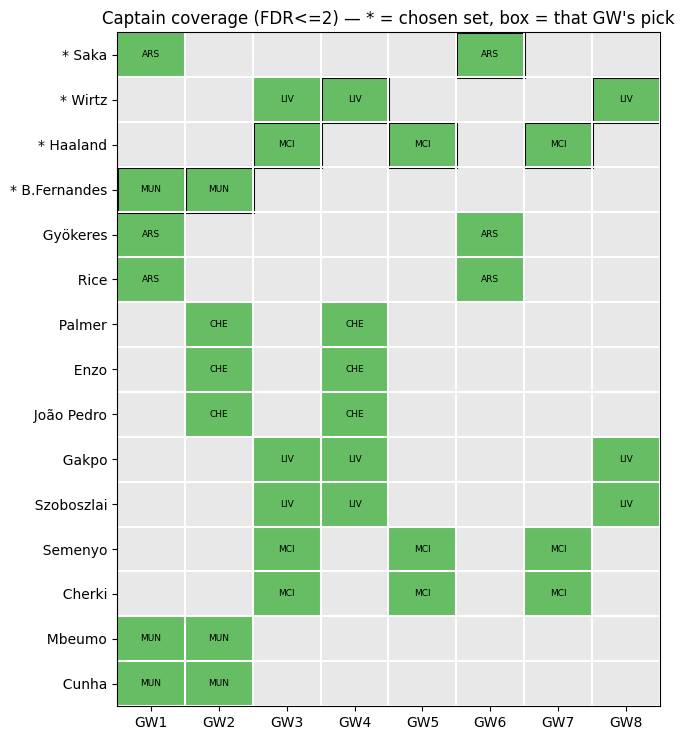

In [23]:
picks = {r.gw.replace("GW", ""): r.captain for r in rota.itertuples()}

order = list(chosen) + [n for n in pool["name"] if n not in chosen]
M = cover.loc[order, gws].astype(float).to_numpy()

cmap = ListedColormap(["#e8e8e8", "#66bd63"])   # 0 = not covered, 1 = covered
fig, ax = plt.subplots(figsize=(1.2 + 0.7 * len(gws), 0.42 * len(order) + 1.2))
ax.imshow(M, cmap=cmap, aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(gws)), [f"GW{g}" for g in gws])
ylabels = [f"{'* ' if n in chosen else '  '}{n}" for n in order]
ax.set_yticks(range(len(order)), ylabels)
ax.set_title(f"Captain coverage (FDR<={T}) — * = chosen set, box = that GW's pick")

pool_team = pool.set_index("name")["team"]
for i, n in enumerate(order):
    for j, gw in enumerate(gws):
        if cover.loc[n, gw]:
            ax.text(j, i, pool_team[n], ha="center", va="center", fontsize=6.5)

# Box the recommended captain per GW.
for j, gw in enumerate(gws):
    cap = picks.get(str(gw))
    if cap in order:
        i = order.index(cap)
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                   edgecolor="black", linewidth=2.2))

ax.set_xticks(np.arange(-0.5, len(gws), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(order), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)
plt.tight_layout()
plt.show()

## Sensitivity — how the set size moves with the threshold `T`

The whole answer hinges on what counts as an "easy" fixture. Here we re-run the exact minimum
cover for each `T` from 2 to 5 and plot how many captains you need — and how many GWs are even
coverable. Stricter `T` (only the softest fixtures count) needs more bodies to paper over the
horizon; looser `T` collapses the set toward one or two names.

,T,captains_needed,GWs_coverable
0,2,4,8
1,3,2,8
2,4,1,8
3,5,1,8


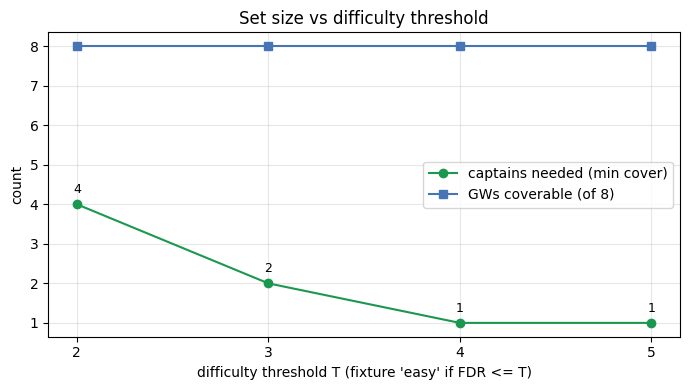

In [24]:
def min_cover_size(threshold):
    cov = {gw: [(pd.notna(team_fdr.loc[r.team, gw]) and team_fdr.loc[r.team, gw] <= threshold)
                for r in pool.itertuples()] for gw in gws}
    covdf = pd.DataFrame(cov, index=pool["name"])
    coverable_t = [gw for gw in gws if covdf[gw].any()]
    if not coverable_t:
        return 0, 0
    b = [sum((1 << gws.index(gw)) for gw in gws if covdf.loc[r.name, gw]) for r in pool.itertuples()]
    A = np.array([[1.0 if (b[i] & (1 << gws.index(g))) else 0.0 for i in range(len(b))]
                  for g in coverable_t])
    r = milp(c=np.ones(len(b)),
             constraints=LinearConstraint(A, lb=np.ones(len(coverable_t)), ub=np.full(len(coverable_t), np.inf)),
             integrality=np.ones(len(b)), bounds=Bounds(np.zeros(len(b)), np.ones(len(b))))
    return int(round(r.x.sum())), len(coverable_t)

sens = pd.DataFrame(
    [(t, *min_cover_size(t)) for t in [2, 3, 4, 5]],
    columns=["T", "captains_needed", "GWs_coverable"],
)
display(sens)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sens["T"], sens["captains_needed"], "-o", color="#1a9850", label="captains needed (min cover)")
ax.plot(sens["T"], sens["GWs_coverable"], "-s", color="#4575b4", label=f"GWs coverable (of {len(gws)})")
for _, row in sens.iterrows():
    ax.annotate(int(row["captains_needed"]), (row["T"], row["captains_needed"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xlabel("difficulty threshold T (fixture 'easy' if FDR <= T)")
ax.set_ylabel("count")
ax.set_xticks(sens["T"])
ax.set_title("Set size vs difficulty threshold")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()